# اهرامات الصور:

### الهدف:
 هنا سوف
 نتعلم
 
 - اهرامات الصور
 
 - سنستخدم اهرامات الصور لانشاء فاكهة جديدة "برتفاح"كما يلي
 - وسنرى التوابع التالية
 `cv2.pyrUp`, `cv2.pyrDown`
 
 
## النظرية: 
 عادة نعمل مع صور ذات قياس ثابت , ولكن قد نحتاج قياسات مختلفة للصورة نفسها احياناً مثل عملية البحث عن وجه والتي تتطلب اخذ قياسات مختلفة لمطابقة الوجه موضع البحث ولذلك ننشأ ما يسمى بهرم الصورة ,لأنها تبدو عند وضعها بشكل متراكم كالهرم فالاقل دقة بالاعلى بينما الاعلى دقة بالادنى, ويتم ذلك حسب نوعين من الاهرامات
** الهرم الغاوسي والهرم اللابلاسي **
تتشكل المستويات العليا للهرم الغاوسي بحذف الاسطر والاعمدة المتعاقبة , بالمستويات الادنى ,  وبعدها يتشكل كل بكسل من الاعلى بتطبيق القناع الغاوسي على 5 بكسلات ادناه , وبذلك يتقلص حجم الصورة للربع ويستمر الامر هكذا وبذلك يتشكل ما يسمى "ثمانيّة"وايضاً تتقلص الدقة , اما اذا تحركنا من الاعلى للادنى فستزيد الدقة والمساحة  ويتم تحقيق ذلك بوساطة التابعين
**cv2.pyrDown** , **cv2.pyrUp**



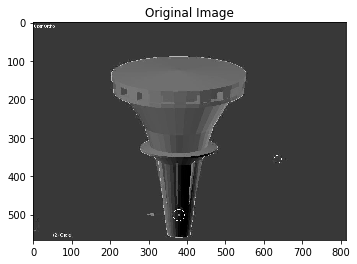

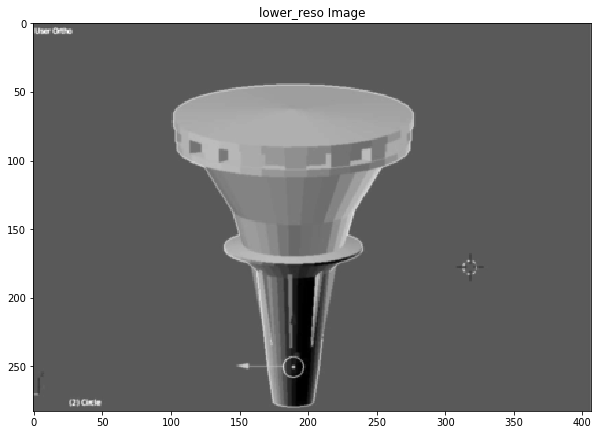

In [1]:
%matplotlib inline

import cv2
import numpy as np
from matplotlib import pyplot as plt

img = cv2.imread('wt.jpg',0)
lower_reso = cv2.pyrDown(img)

plt.imshow(img,cmap = 'gray')
plt.title('Original Image')
plt.show()

plt.figure(figsize=[10,10])
plt.imshow(lower_reso,cmap = 'gray')
plt.title('lower_reso Image')
plt.show()
None

In [2]:
print img.shape
print lower_reso.shape

(566, 814)
(283, 407)


والان يمكنك التحرك للاسفل بالهرم مع التابع وفق الاتي

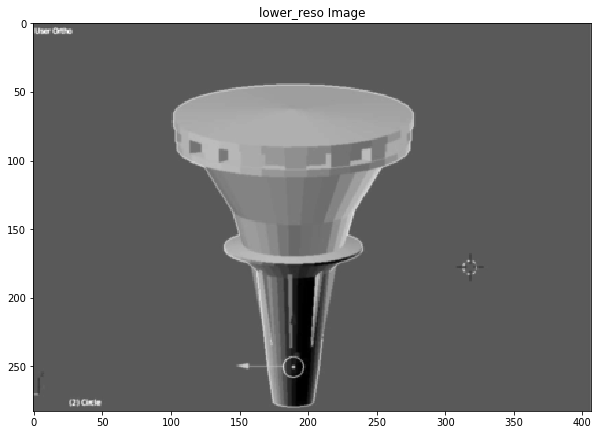

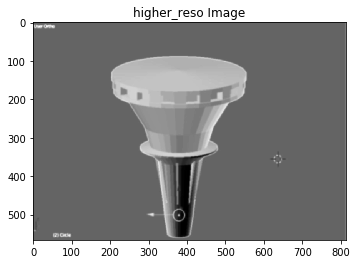

In [3]:
higher_reso = cv2.pyrUp(lower_reso)

plt.figure(figsize=[10,10])

plt.imshow(lower_reso,cmap = 'gray')
plt.title('lower_reso Image')
plt.show()

plt.imshow(higher_reso,cmap = 'gray')
plt.title('higher_reso Image')
plt.show()
None

و لكن تذكر ان الصورة الناتجة عن النزول في الهرم تختلف عن الصورة الاصلية لان توليد صور اقل دقة يحذف معلومات من الصورة , ولذلك تكون مختلفة بامكانك ملاحظة الفرق في السابق كالتالي

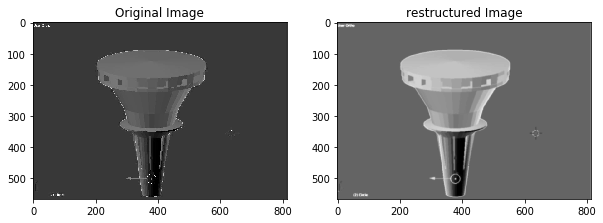

In [4]:
plt.figure(figsize=[10,10])
plt.subplot(121)
plt.imshow(img,cmap = 'gray')
plt.title('Original Image')

plt.subplot(122)
plt.imshow(higher_reso,cmap = 'gray')
plt.title('restructured Image')
plt.show()
None

**الاهرامات اللابلاسية ** تتشكل من الاهرامات الغاوسية  , ولا يوجد تابع مخصص لها .
وهي تماثل الصور للحواف فقط  ومعظم عناصرها اصفار  , وتستخدم لتقنيات ضغط الصور  , ويتشكل المستوي فيها من فرق المستوي المناظر للهرم الغاوسي مع النسخة المكبر ة للمستوي ادناه , ويمكن اجراء ذلك حسابيا ومقارنة النتائج

## : دمج الصور باستخدام الاهرامات
احدى التطبيقات للاهرامات هو الدمج
**blending**
للصور المختلفة مثلاً , بتطبيقات دمج الصور قد نحتاج لصق صورتين معاً من دون فقدان الكثير من البيانات , واعطاء مظهر متماثل واحد الامثلة الكلاسيكية لهذا هو لصق صورتين لتفاحة وبرتقالة 
كماالصورة التالية 

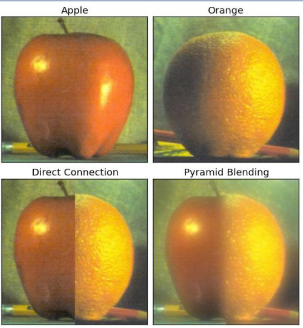

In [7]:
from IPython.display import Image
Image('prblend0.png')

الرجاء العودة للمرجع في النهاية لاحتوئه على معلومات تفصيلية عن دمج الصور والاهرامات اللابلاسية . وببساطة يشرح التالي العملية


### **اولا-حمل صور التفاحة والبرتقالة**


In [6]:
import cv2
import numpy as np,sys

A = cv2.imread('apple.png')
B = cv2.imread('orange.png')


### **ثانيا-اوجد الهرم الغاوسي لكل منهما :تحديدا هنا 6 مستويات**


In [7]:
# generate Gaussian pyramid for A
G = A.copy()
gpA = [G]
for i in xrange(6):
    G = cv2.pyrDown(G)
    gpA.append(G)
    
# generate Gaussian pyramid for B
G = B.copy()
gpB = [G]
for i in xrange(6):
    G = cv2.pyrDown(G)
    gpB.append(G)


### ثالثاً- ومن الاهرامات الغاوسية اوجد الاهرامات اللابلاسية 


In [45]:
# generate Laplacian Pyramid for A
lpA = [gpA[5]]
for i in xrange(5,0,-1):
    GE = cv2.pyrUp(gpA[i])
    if gpA[i-1].shape!=GE.shape:GE1 = GE[:-1][:,:-1]
    else:GE1=GE;
    L = cv2.subtract(gpA[i-1],GE1)
    lpA.append(L)
    
# generate Laplacian Pyramid for B
lpB = [gpB[5]]
for i in xrange(5,0,-1):
    GE = cv2.pyrUp(gpB[i])
    if gpB[i-1].shape!=GE.shape:GE2 = GE[:-1][:,:-1]
    else:GE2=GE;
    L = cv2.subtract(gpB[i-1],GE2)
    lpB.append(L)

((15, 15, 3), (15, 15, 3))
((30, 30, 3), (30, 30, 3))
((60, 60, 3), (60, 60, 3))
((120, 120, 3), (120, 120, 3))
((239, 239, 3), (239, 239, 3))
((16, 16, 3), (15, 15, 3))
((30, 30, 3), (30, 30, 3))
((60, 60, 3), (60, 60, 3))
((120, 120, 3), (120, 120, 3))
((240, 240, 3), (239, 239, 3))



### رابعاً - اجمع القسم الايسر من التفاحة والقسم الايمن من البرتقالة بكل مستوى من الهرم اللابلاسي


In [46]:
# Now add left and right halves of images in each level
LS = []
for la,lb in zip(lpA,lpB):
    rows,cols,dpt = la.shape
    ls = np.hstack((la[:,0:cols/2], lb[:,cols/2:]))
    LS.append(ls)
    

### خامساً - واخيرا من الصور المجموعة بالهرم شكل الصورة الاصلية


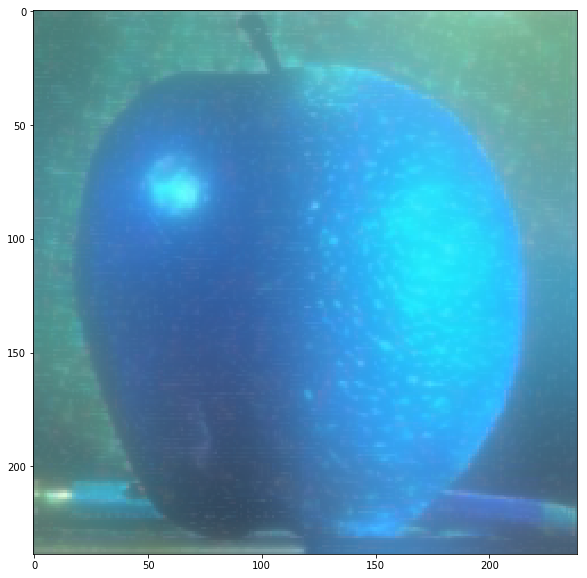

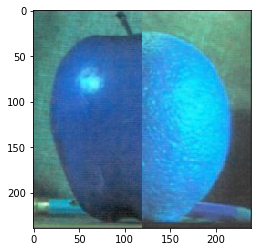

In [63]:
# now reconstruct
ls_ = LS[0]
for i in xrange(1,6):
    ls_ = cv2.pyrUp(ls_)
    if LS[i].shape!=ls_.shape:ls_1= ls_[:-1][:,:-1]
    else:ls_1=ls_;
    
    ls_ = cv2.add(ls_1, LS[i])
    
# image with direct connecting each half
real = np.hstack((A[:,:cols/2],B[:,cols/2:]))

plt.figure(figsize=[10,10])
plt.imshow(ls_,cmap='gray')
plt.show()

plt.imshow(real,cmap='gray')
plt.show()



وهكذا تم البرنامج بالكامل ولغرض البساطة كل خطوة تتم لوحدها على الرغم من ان هذا يستهلك ذاكرة ولكن فقط للايضاح
,والناتج سيكون كما أعلاه

## المراجع الاضافية:
http://pages.cs.wisc.edu/~csverma/CS766_09/ImageMosaic/imagemosaic.html